In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

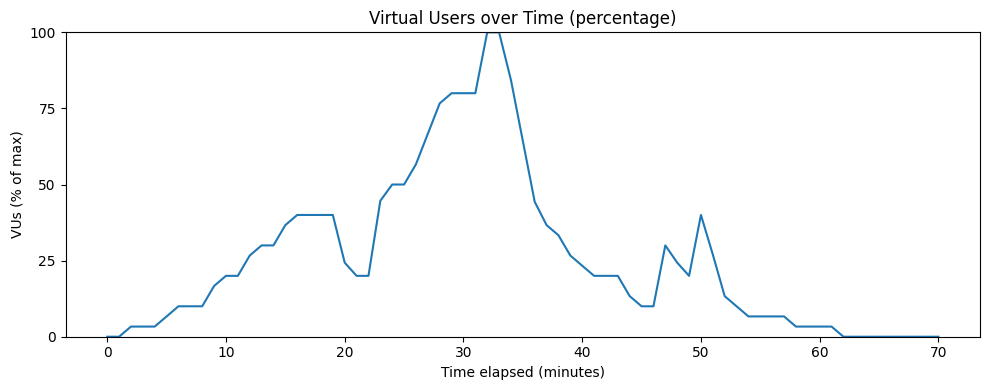

In [2]:
df = pd.read_csv("10_pod.csv", comment="#")
df["time"] = pd.to_datetime(df["_time"], utc=True)
df["value"] = pd.to_numeric(df["_value"], errors="coerce").fillna(0.0)
df = df[["time", "value"]].sort_values("time")
t0 = df["time"].iloc[0]
df["elapsed_minute"] = (df["time"] - t0).dt.total_seconds() / 60.0
# Convert values to percentage of max (0-100%) so different scenario scales are comparable
max_vus = df["value"].max()
if max_vus > 0:
    df["value_pct"] = df["value"] / max_vus * 100.0
else:
    df["value_pct"] = 0.0
# Shift series by +2 minutes to add 2 minutes of zeros at the start, and pad +8 minutes at the end
df["elapsed_minute"] = df["elapsed_minute"] + 2.0
end_time = df["elapsed_minute"].max()
total_end = end_time + 8.0
# Build 1-minute grid from 0 to total_end and interpolate values; missing areas become zeros
minutes = np.arange(0, int(np.ceil(total_end)) + 1)
interp_values = np.interp(minutes, df["elapsed_minute"], df["value_pct"], left=0.0, right=0.0)
df_minutes = pd.DataFrame({"elapsed_minute": minutes, "value_pct": interp_values})
plt.figure(figsize=(10, 4))
plt.plot(df_minutes["elapsed_minute"], df_minutes["value_pct"])
plt.xlabel("Time elapsed (minutes)")
plt.ylabel("VUs (% of max)")
plt.title("Virtual Users over Time (percentage)")
plt.ylim(0, 100)
plt.yticks([0, 25, 50, 75, 100])
plt.tight_layout()
plt.savefig("vus_timeseries.png", dpi=300)
plt.show()

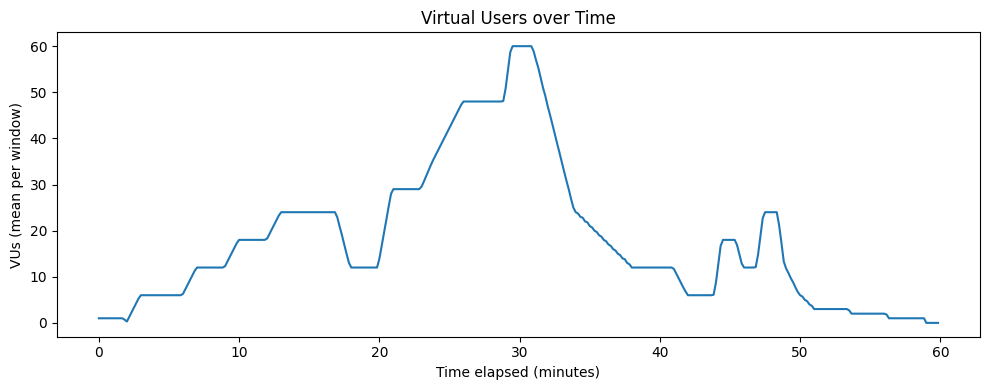

In [ ]:
df = pd.read_csv("20_pod.csv", comment="#")
df["time"] = pd.to_datetime(df["_time"], utc=True)
df["value"] = pd.to_numeric(df["_value"], errors="coerce").fillna(0.0)
df = df[["time", "value"]].sort_values("time")
t0 = df["time"].iloc[0]
df["elapsed_minute"] = (df["time"] - t0).dt.total_seconds() / 60.0
# Convert values to percentage of max (0-100%) so different scenario scales are comparable
max_vus = df["value"].max()
if max_vus > 0:
    df["value_pct"] = df["value"] / max_vus * 100.0
else:
    df["value_pct"] = 0.0
# Shift series by +2 minutes to add 2 minutes of zeros at the start, and pad +8 minutes at the end
df["elapsed_minute"] = df["elapsed_minute"] + 2.0
end_time = df["elapsed_minute"].max()
total_end = end_time + 8.0
# Build 1-minute grid from 0 to total_end and interpolate values; missing areas become zeros
minutes = np.arange(0, int(np.ceil(total_end)) + 1)
interp_values = np.interp(minutes, df["elapsed_minute"], df["value_pct"], left=0.0, right=0.0)
df_minutes = pd.DataFrame({"elapsed_minute": minutes, "value_pct": interp_values})
plt.figure(figsize=(10, 4))
plt.plot(df_minutes["elapsed_minute"], df_minutes["value_pct"])
plt.xlabel("Time elapsed (minutes)")
plt.ylabel("VUs (% of max)")
plt.title("Virtual Users over Time (percentage)")
plt.ylim(0, 100)
plt.yticks([0, 25, 50, 75, 100])
plt.tight_layout()
plt.savefig("vus_timeseries.png", dpi=300)
plt.show()
